### **Importing Libraries**

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub
from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

### **Setting Options**

In [42]:
# Ensure that all columns are displayed when printing a DataFrame
pd.set_option('display.max_columns', None)

### **Retrieving Data from Kaggle**
https://www.kaggle.com/datasets/uom190346a/mental-health-research-dataset/data

In [6]:
# set path
path = kagglehub.dataset_download("uom190346a/mental-health-research-dataset")
# print out the path of downloaded files
print(path)

100%|██████████| 13.8k/13.8k [00:00<00:00, 1.88MB/s]

Extracting files...
C:\Users\heppe\.cache\kagglehub\datasets\uom190346a\mental-health-research-dataset\versions\1


You will need to retrieve the csv file from the stated path if you want to re-create this method. Otherwise I have uploaded the csv to this repository and will be accessing it from there for the rest of this project

### **Data Loading and Familiarisation**

In [72]:
# read csv
mh = pd.read_csv("Mental_Health_and_Lifestyle_Research.csv")

In [8]:
# head
mh.head()

,Person_ID,Age,Gender,Hours_of_Sleep,Stress_Level,Physical_Activity,Work_Hours_per_Day,Mental_Health_Status,Social_Interaction_Freq,Overall_Wellbeing_Score,Diet_Quality,Screen_Time_per_Day,Substance_Use,Has_Close_Friends,Physical_Health_Condition
0,1,25,Male,7,7,13,9,Mild Anxiety,Low,3,Excellent,8.8,NaN,True,NaN
1,2,34,Female,7,4,46,9,Depression,Moderate,5,Fair,5.1,Alcohol,True,Hypertension
2,3,31,Female,5,6,34,8,NaN,Moderate,4,Fair,6.6,Smoking,True,Obesity
3,4,29,Female,6,7,30,11,Depression,Moderate,2,Good,7.6,Alcohol,True,NaN
4,5,22,Female,7,5,10,7,NaN,Moderate,4,Very Good,6.5,Alcohol,True,Obesity


In [11]:
# information about data types and NAs
mh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person_ID                  1000 non-null   int64  
 1   Age                        1000 non-null   int64  
 2   Gender                     1000 non-null   str    
 3   Hours_of_Sleep             1000 non-null   int64  
 4   Stress_Level               1000 non-null   int64  
 5   Physical_Activity          1000 non-null   int64  
 6   Work_Hours_per_Day         1000 non-null   int64  
 7   Mental_Health_Status       358 non-null    str    
 8   Social_Interaction_Freq    1000 non-null   str    
 9   Overall_Wellbeing_Score    1000 non-null   int64  
 10  Diet_Quality               1000 non-null   str    
 11  Screen_Time_per_Day        1000 non-null   float64
 12  Substance_Use              621 non-null    str    
 13  Has_Close_Friends          1000 non-null   bool   
 14  Phys

In [12]:
# look for data ranges
mh.describe()

,Person_ID,Age,Hours_of_Sleep,Stress_Level,Physical_Activity,Work_Hours_per_Day,Overall_Wellbeing_Score,Screen_Time_per_Day
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,27.076000,6.950000,5.46900,28.954000,7.994000,4.094000,7.088500
std,288.819436,4.578995,1.127285,2.03892,18.024671,1.412076,2.131128,1.984433
min,1.000000,20.000000,5.000000,1.00000,0.000000,5.000000,1.000000,1.000000
25%,250.750000,23.000000,6.000000,4.00000,15.000000,7.000000,2.000000,5.800000
50%,500.500000,27.000000,7.000000,5.00000,29.000000,8.000000,4.000000,7.100000
75%,750.250000,31.000000,8.000000,7.00000,41.000000,9.000000,6.000000,8.400000
max,1000.000000,35.000000,9.000000,10.00000,93.000000,11.000000,10.000000,12.000000


### **Data Cleaning**
There are a lot of `NaN` entries in some of the categorical columns:
- `Mental_Health_Status`
- `Substance_Use`
- `Physical_Health_Status`

Looking at the [Kaggle documentation](https://www.kaggle.com/datasets/uom190346a/mental-health-research-dataset/data), this would appear to be pandas interpreting `"None"` as `NaN` - going to replace `NaN` with a string.

In [73]:
# replace NaN
mh.fillna("None", inplace=True)

# check it worked
mh.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person_ID                  1000 non-null   int64  
 1   Age                        1000 non-null   int64  
 2   Gender                     1000 non-null   str    
 3   Hours_of_Sleep             1000 non-null   int64  
 4   Stress_Level               1000 non-null   int64  
 5   Physical_Activity          1000 non-null   int64  
 6   Work_Hours_per_Day         1000 non-null   int64  
 7   Mental_Health_Status       1000 non-null   str    
 8   Social_Interaction_Freq    1000 non-null   str    
 9   Overall_Wellbeing_Score    1000 non-null   int64  
 10  Diet_Quality               1000 non-null   str    
 11  Screen_Time_per_Day        1000 non-null   float64
 12  Substance_Use              1000 non-null   str    
 13  Has_Close_Friends          1000 non-null   bool   
 14  Phys

As per the `describe()` output, all of the continuous variables appear to have plausible ranges

### **Pre-Processing**

One-Hot Encoding categorical variables

In [74]:
# initialise one hot encoder with sparse output and pandas output
encoder = OneHotEncoder(sparse_output=False)
encoder.set_output(transform="pandas")
encoder_cols = ["Mental_Health_Status", "Substance_Use", "Physical_Health_Condition"]

# fit and transform relevant columns
encoded_data = encoder.fit_transform(mh[encoder_cols])
mh[encoded_data.columns] = encoded_data

# drop original columns
mh.drop(columns=encoder_cols, inplace=True)
# also drop None columns
mh.drop(columns=["Mental_Health_Status_None", "Substance_Use_None", "Physical_Health_Condition_None"], inplace=True)
# drop person ID
mh.drop(columns=["Person_ID"], inplace=True)

# not necessary to have 2 columns for Gender and Has_Close_Friends - just apply lambda function
mh["Gender"] = mh["Gender"].apply(lambda x: 1 if x == "Male" else 0)
mh["Has_Close_Friends"] = mh["Has_Close_Friends"].apply(lambda x: 1 if x else 0)

# checking it worked
mh.head()

,Age,Gender,Hours_of_Sleep,Stress_Level,Physical_Activity,Work_Hours_per_Day,Social_Interaction_Freq,Overall_Wellbeing_Score,Diet_Quality,Screen_Time_per_Day,Has_Close_Friends,Mental_Health_Status_Depression,Mental_Health_Status_Mild Anxiety,Mental_Health_Status_Moderate Anxiety,Mental_Health_Status_Severe Anxiety,Substance_Use_Alcohol,Substance_Use_Both,Substance_Use_Smoking,Physical_Health_Condition_Diabetes,Physical_Health_Condition_Hypertension,Physical_Health_Condition_Obesity,Physical_Health_Condition_Other Chronic Illness
0,25,1,7,7,13,9,Low,3,Excellent,8.8,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,34,0,7,4,46,9,Moderate,5,Fair,5.1,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,31,0,5,6,34,8,Moderate,4,Fair,6.6,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,29,0,6,7,30,11,Moderate,2,Good,7.6,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,22,0,7,5,10,7,Moderate,4,Very Good,6.5,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [47]:
mh.head()

,Person_ID,Age,Gender,Hours_of_Sleep,Stress_Level,Physical_Activity,Work_Hours_per_Day,Social_Interaction_Freq,Overall_Wellbeing_Score,Diet_Quality,Screen_Time_per_Day,Has_Close_Friends,Mental_Health_Status_Depression,Mental_Health_Status_Mild Anxiety,Mental_Health_Status_Moderate Anxiety,Mental_Health_Status_None,Mental_Health_Status_Severe Anxiety,Substance_Use_Alcohol,Substance_Use_Both,Substance_Use_None,Substance_Use_Smoking,Physical_Health_Condition_Diabetes,Physical_Health_Condition_Hypertension,Physical_Health_Condition_None,Physical_Health_Condition_Obesity,Physical_Health_Condition_Other Chronic Illness
0,1,25,1,7,7,13,9,Low,3,Excellent,8.8,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2,34,0,7,4,46,9,Moderate,5,Fair,5.1,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3,31,0,5,6,34,8,Moderate,4,Fair,6.6,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,4,29,0,6,7,30,11,Moderate,2,Good,7.6,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5,22,0,7,5,10,7,Moderate,4,Very Good,6.5,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Some columns are ordinal - going to turn them into numbers (`Social_Interaction_Freq` and `Diet_Quality`)

In [49]:
# identify levels
print(mh["Social_Interaction_Freq"].value_counts())
print(mh["Diet_Quality"].value_counts())

Social_Interaction_Freq
Moderate    506
Low         311
High        183
Name: count, dtype: int64
Diet_Quality
Good         405
Fair         243
Very Good    218
Poor          69
Excellent     65
Name: count, dtype: int64


In [75]:
# create dictionaries to map the levels to numerical values
SI_map = {
    "Low": 0,
    "Moderate": 1,
    "High": 2
}

DQ_map = {
    "Poor": 0,
    "Fair": 1,
    "Good": 2,
    "Very Good": 3,
    "Excellent": 4
}

mh["Social_Interaction_Freq"] = mh["Social_Interaction_Freq"].map(SI_map)
mh["Diet_Quality"] = mh["Diet_Quality"].map(DQ_map)

Scaling continuous variables

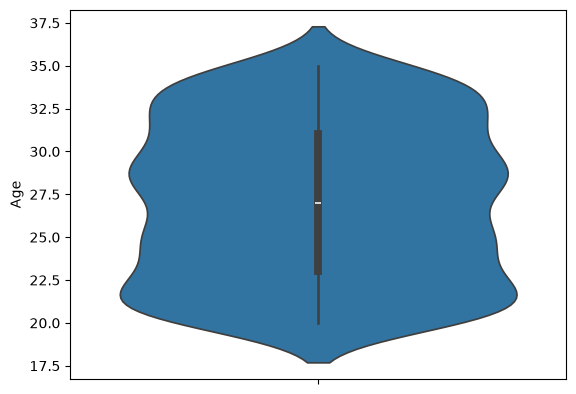

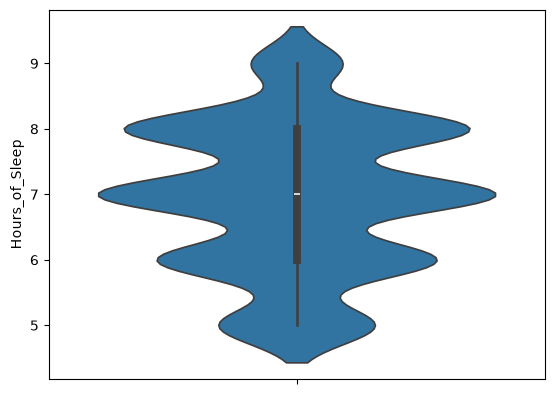

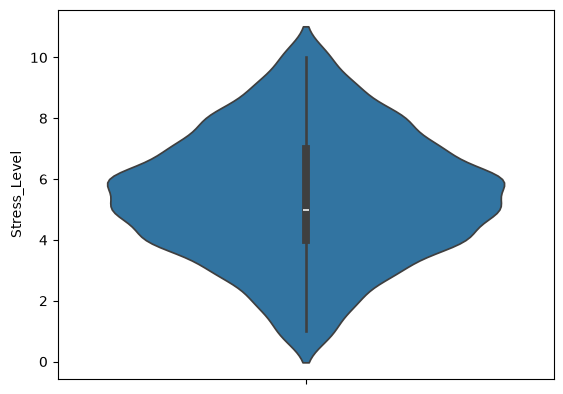

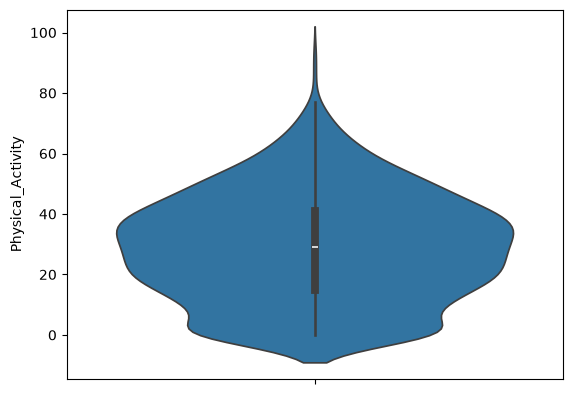

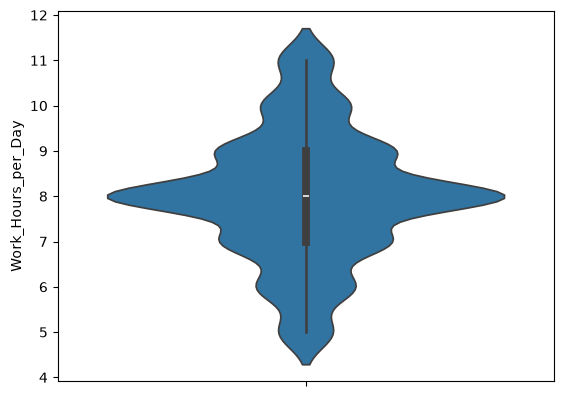

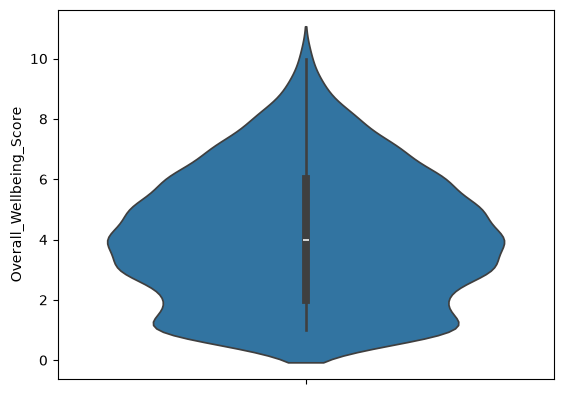

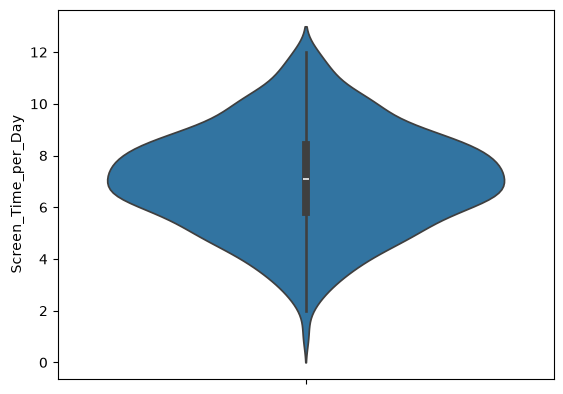

In [65]:
## selecting what kind of scaler to use (ie. how bad are the outliers?) ##

# defining continuous columns
continuous_cols = ["Age", "Hours_of_Sleep", "Stress_Level", "Physical_Activity","Work_Hours_per_Day",
                    "Overall_Wellbeing_Score", "Screen_Time_per_Day"]

for col in continuous_cols:
    sns.violinplot(y=mh[col])
    plt.show()

In [76]:
# Physical activity and wellbeing score are skewed - Robust Scaler
# Everything else looks normally distributed - Standard Scaler
robust_cols = ["Physical_Activity", "Overall_Wellbeing_Score"]
standard_cols = [col for col in continuous_cols if col not in robust_cols]

standard_scaler = StandardScaler()
standard_scaler.fit(mh[standard_cols])
standard_transformed = standard_scaler.transform(mh[standard_cols])

for i, col in enumerate(standard_cols):
    mh[col] = standard_transformed[:, i]

robust_scaler = RobustScaler()
robust_scaler.fit(mh[robust_cols])
robust_transformed = robust_scaler.transform(mh[robust_cols])

for i, col in enumerate(robust_cols):
    mh[col] = robust_transformed[:, i]

In [ ]:
# checking it worked
mh.head()

,Person_ID,Age,Gender,Hours_of_Sleep,Stress_Level,Physical_Activity,Work_Hours_per_Day,Social_Interaction_Freq,Overall_Wellbeing_Score,Diet_Quality,Screen_Time_per_Day,Has_Close_Friends,Mental_Health_Status_Depression,Mental_Health_Status_Mild Anxiety,Mental_Health_Status_Moderate Anxiety,Mental_Health_Status_None,Mental_Health_Status_Severe Anxiety,Substance_Use_Alcohol,Substance_Use_Both,Substance_Use_None,Substance_Use_Smoking,Physical_Health_Condition_Diabetes,Physical_Health_Condition_Hypertension,Physical_Health_Condition_None,Physical_Health_Condition_Obesity,Physical_Health_Condition_Other Chronic Illness
0,1,-0.453601,1,0.044377,0.751263,-0.615385,0.712783,0,-0.25,4,0.862894,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2,1.512879,0,0.044377,-0.720840,0.653846,0.712783,1,0.25,1,-1.002551,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3,0.857385,0,-1.730686,0.260562,0.192308,0.004251,1,0.00,1,-0.246289,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,4,0.420390,0,-0.843155,0.751263,0.038462,2.129846,1,-0.50,2,0.257885,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5,-1.109095,0,0.044377,-0.230139,-0.730769,-0.704280,1,0.00,3,-0.296707,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### **Analysis**

Need to get the position of the categorical columns

In [ ]:
# get list of the columns
mh.columns

Index(['Age', 'Gender', 'Hours_of_Sleep', 'Stress_Level', 'Physical_Activity',
       'Work_Hours_per_Day', 'Social_Interaction_Freq',
       'Overall_Wellbeing_Score', 'Diet_Quality', 'Screen_Time_per_Day',
       'Has_Close_Friends', 'Mental_Health_Status_Depression',
       'Mental_Health_Status_Mild Anxiety',
       'Mental_Health_Status_Moderate Anxiety',
       'Mental_Health_Status_Severe Anxiety', 'Substance_Use_Alcohol',
       'Substance_Use_Both', 'Substance_Use_Smoking',
       'Physical_Health_Condition_Diabetes',
       'Physical_Health_Condition_Hypertension',
       'Physical_Health_Condition_Obesity',
       'Physical_Health_Condition_Other Chronic Illness'],
      dtype='str')

In [ ]:
# get number of columns - after about half way, it'll be all categorical
len(mh.columns)

22

In [84]:
cat_cols = [2] + list(range(11, 22))
cat_cols

[2, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]

Convert data frame to matrix

In [85]:
mh_matrix = mh.to_numpy()